<a href="https://colab.research.google.com/github/Leke242/HTML/blob/main/machine_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the necessart libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [6]:
from google.colab import files
uploaded = files.upload()

Saving sales (1).csv to sales (1).csv


Loading the datase

In [7]:
df=pd.read_csv("sales.csv",encoding="latin1")
print(df.head())
print(df.shape)
print(df.info)

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye           NaN

Cleanind the data

In [9]:
print(df.isnull().sum())


ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64


Convert text to number and split the data

In [18]:
X = df[['QUANTITYORDERED','PRICEEACH','MONTH_ID','YEAR_ID']]
y = df['DEALSIZE']

le = LabelEncoder()

y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)


Train the model and make predictions

In [20]:
model= DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)





Evaluate the model

In [22]:
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

print(classification_report(y_test, y_pred))

accuracy: 0.8813559322033898
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.87      0.90      0.88        29
           2       0.93      0.90      0.91        29

    accuracy                           0.88        59
   macro avg       0.60      0.60      0.60        59
weighted avg       0.88      0.88      0.88        59



Create a confusion matrix

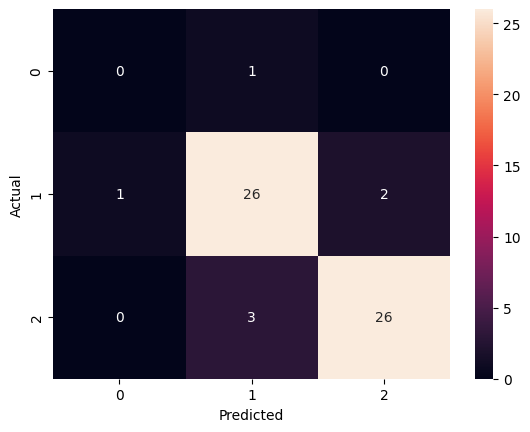

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

line graph

New prediction using new data

In [34]:
new_order = [[30, 100, 11, 2004]]

prediction = model.predict(new_order)

print("Predicted Deal Size:", le.inverse_transform(prediction))

Predicted Deal Size: ['Medium']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Linear Regression

creating the datset

In [36]:
# Dataset
data={
 'hours' :  [1,2,3,4,5,6],
 'scores':[50,55,65,70,75,85]

}
df1=pd.DataFrame(data)
print(df1)

   hours  scores
0      1      50
1      2      55
2      3      65
3      4      70
4      5      75
5      6      85


Visualize the data

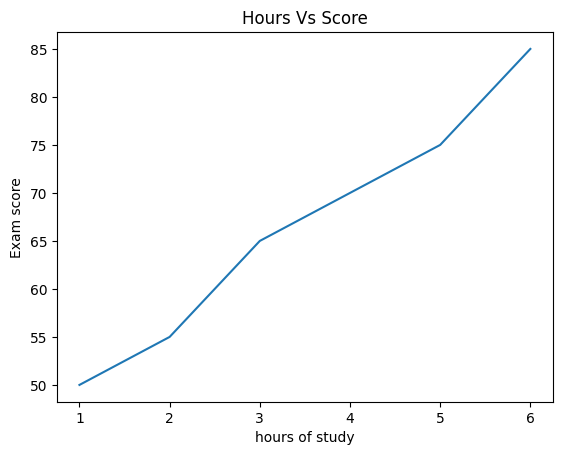

In [40]:
plt.plot(df1['hours'],df1['scores'])
plt.xlabel("hours of study")
plt.ylabel("Exam score")
plt.title("Hours Vs Score")
plt.show()



Train the model

In [47]:
x=df1[['hours']]
y=df1['scores']

x_train1,x_test1,y_train1,y_test1=train_test_split(x,y,test_size=0.2,random_state=42)

model= LinearRegression()

model.fit(x_train1,y_train1)
y_pred1 = model.predict(x_test1)



